# Klasifikasi Kualitas Anggur (Wine Quality Classification)

**Nama:** Hayu Dhiya Rahmadani

**NIM:** 2304020005

## 1. Import Library

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

import warnings
warnings.filterwarnings('ignore')

---
## 2. Load Dataset

Dataset yang digunakan terdiri dari dua file:
- `data_training.csv` → digunakan untuk melatih model
- `data_testing.csv` → digunakan untuk memprediksi kualitas anggur (tanpa label)


In [45]:
df_train = pd.read_csv('data_training.csv')
df_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [46]:
df_test  = pd.read_csv('data_testing.csv')
df_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


In [47]:
print('Shape data training :', df_train.shape)
print('Shape data testing  :', df_test.shape)
df_train.head()

Shape data training : (857, 13)
Shape data testing  : (286, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [48]:
df_test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


---
## 3. Eksplorasi Data (EDA)

Sebelum membangun model, perlu dilakukan eksplorasi data untuk memahami karakteristik dataset, termasuk tipe data, distribusi nilai, dan statistik deskriptif dari setiap variabel.

Variabel-variabel dalam dataset ini antara lain:
1. **fixed acidity** – Kadar asam tetap dalam anggur
2. **volatile acidity** – Kadar asam volatil; nilai tinggi dapat menyebabkan rasa cuka
3. **citric acid** – Asam sitrat yang menambah kesegaran rasa
4. **residual sugar** – Kadar gula yang tersisa setelah fermentasi
5. **chlorides** – Kadar garam dalam anggur
6. **free sulfur dioxide** – SO2 bebas yang mencegah pertumbuhan mikroba
7. **total sulfur dioxide** – Total SO2 (bebas + terikat)
8. **density** – Kerapatan anggur
9. **pH** – Tingkat keasaman anggur
10. **sulphates** – Aditif yang berkontribusi pada SO2
11. **alcohol** – Kadar alkohol dalam anggur
12. **type** – Jenis anggur (red/white)
13. **quality** – **(Target)** Kualitas anggur skala 0–10

In [49]:
# Informasi umum dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [50]:
# Statistik deskriptif
df_train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Statistik deskriptif di atas menunjukkan ringkasan nilai minimum, maksimum, rata-rata, dan standar deviasi dari setiap fitur. Terlihat bahwa nilai antar fitur bervariasi cukup besar, misalnya `total sulfur dioxide` memiliki rentang yang jauh lebih besar dibandingkan `citric acid`. Hal ini perlu diperhatikan saat memilih model yang sensitif terhadap skala fitur.

Distribusi kelas quality:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


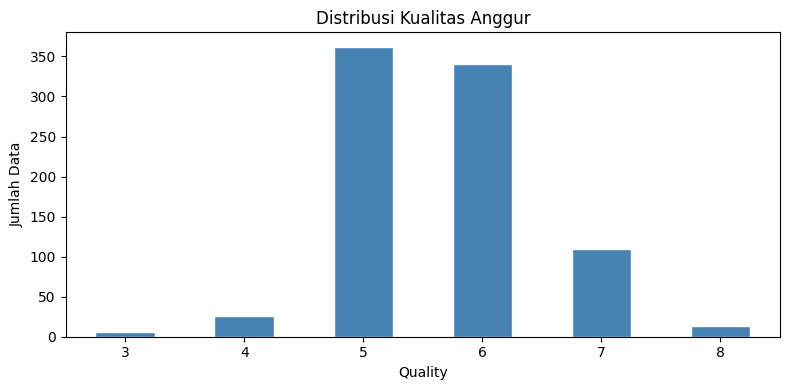

In [51]:
# Distribusi nilai target (quality)
print('Distribusi kelas quality:')
print(df_train['quality'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df_train['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribusi Kualitas Anggur')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Dari distribusi di atas, terlihat bahwa sebagian besar data memiliki nilai kualitas 5 dan 6. Kelas dengan kualitas sangat rendah (3) atau sangat tinggi (8-9) memiliki jumlah data yang jauh lebih sedikit. Ini menunjukkan adanya **ketidakseimbangan kelas (class imbalance)** yang perlu diperhatikan dalam evaluasi model.

**1. Distribusi setiap fitur kimia**

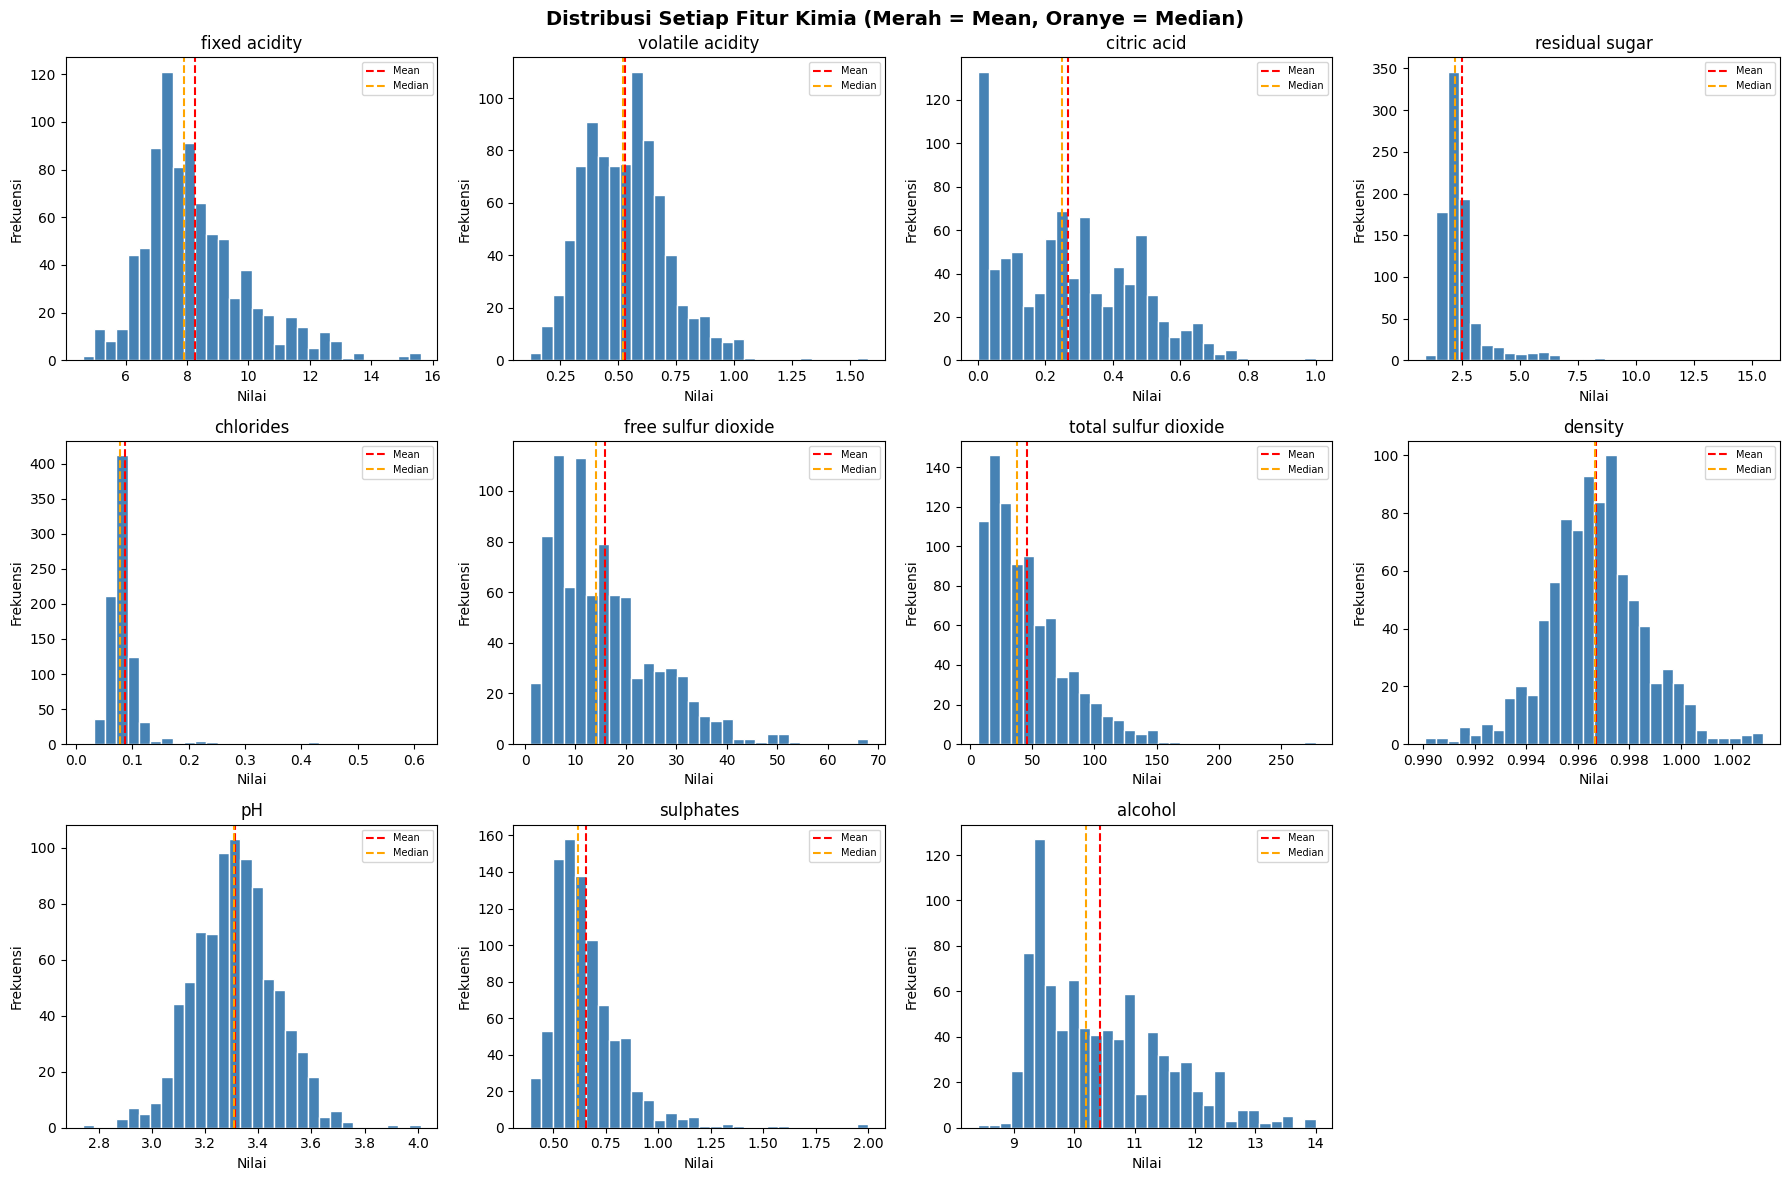

In [52]:
fitur_kimia = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
               'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
               'pH', 'sulphates', 'alcohol']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle('Distribusi Setiap Fitur Kimia (Merah = Mean, Oranye = Median)', fontsize=14, fontweight='bold')

for i, fitur in enumerate(fitur_kimia):
    axes[i].hist(df_train[fitur], bins=30, color='steelblue', edgecolor='white')
    axes[i].axvline(df_train[fitur].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df_train[fitur].median(), color='orange', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_title(fitur)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=7)

# Sembunyikan subplot kosong
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Berdasarkan histogram di atas, beberapa fitur seperti residual sugar, chlorides, dan total sulfur dioxide memiliki distribusi yang right-skewed (condong ke kanan), ditandai dengan mean yang lebih besar dari median. Hal ini menunjukkan adanya outlier dengan nilai yang sangat tinggi pada fitur-fitur tersebut.

**2. Distribusi Kelas Quality & Boxplot Alcohol per Quality**

Visualisasi ini menampilkan dua informasi penting: distribusi jumlah data per kelas quality, dan hubungan antara kadar alkohol dengan kelas quality.

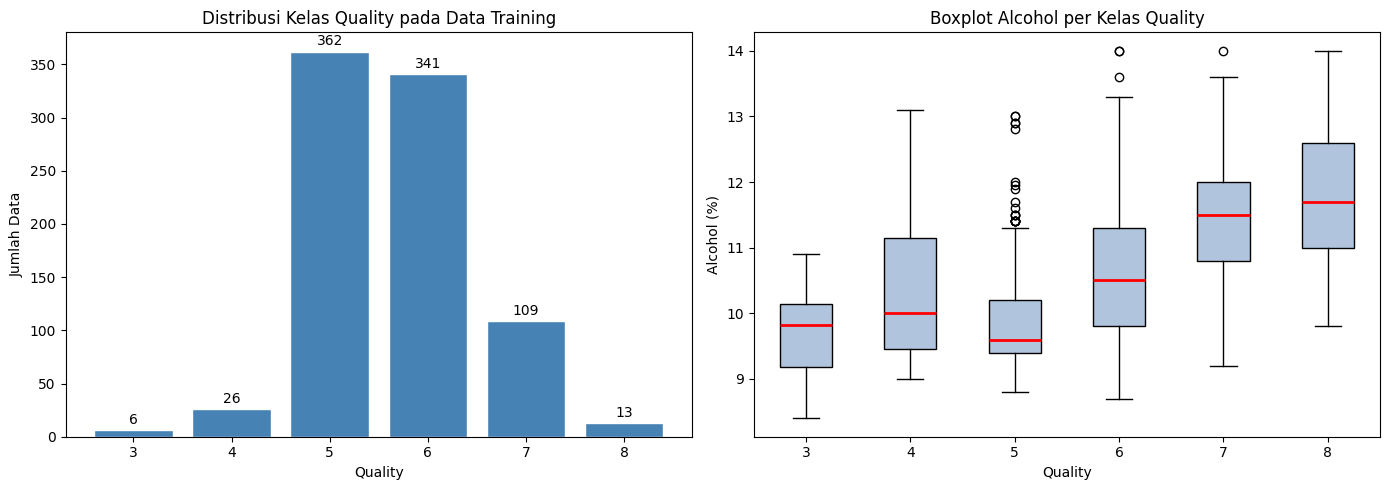

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Bar chart distribusi kelas quality ---
quality_counts = df_train['quality'].value_counts().sort_index()
bars = axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Kelas Quality pada Data Training')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Jumlah Data')

# Tambahkan label angka di atas bar
for bar, val in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=10)

# --- Plot 2: Boxplot alcohol per kelas quality ---
quality_groups = [df_train[df_train['quality'] == q]['alcohol'].values
                  for q in sorted(df_train['quality'].unique())]

bp = axes[1].boxplot(quality_groups,
                     labels=sorted(df_train['quality'].unique()),
                     patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))

for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')

axes[1].set_title('Boxplot Alcohol per Kelas Quality')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Alcohol (%)')

plt.tight_layout()
plt.show()

Dari distribusi kelas, terlihat jelas bahwa data didominasi oleh quality 5 dan 6, sementara quality 3 dan 8 sangat sedikit — menunjukkan adanya class imbalance. Boxplot alcohol menunjukkan tren yang jelas: semakin tinggi kelas quality, semakin tinggi pula median kadar alkohol. Ini mengkonfirmasi bahwa alcohol adalah fitur yang sangat berpengaruh terhadap kualitas anggur.

**3. Distribusi Semua Fitur per Kelas Quality (Boxplot)**

Boxplot berikut menampilkan distribusi setiap fitur kimiawi berdasarkan kelas quality, sehingga dapat terlihat fitur mana yang memiliki pola berbeda antar kelas.

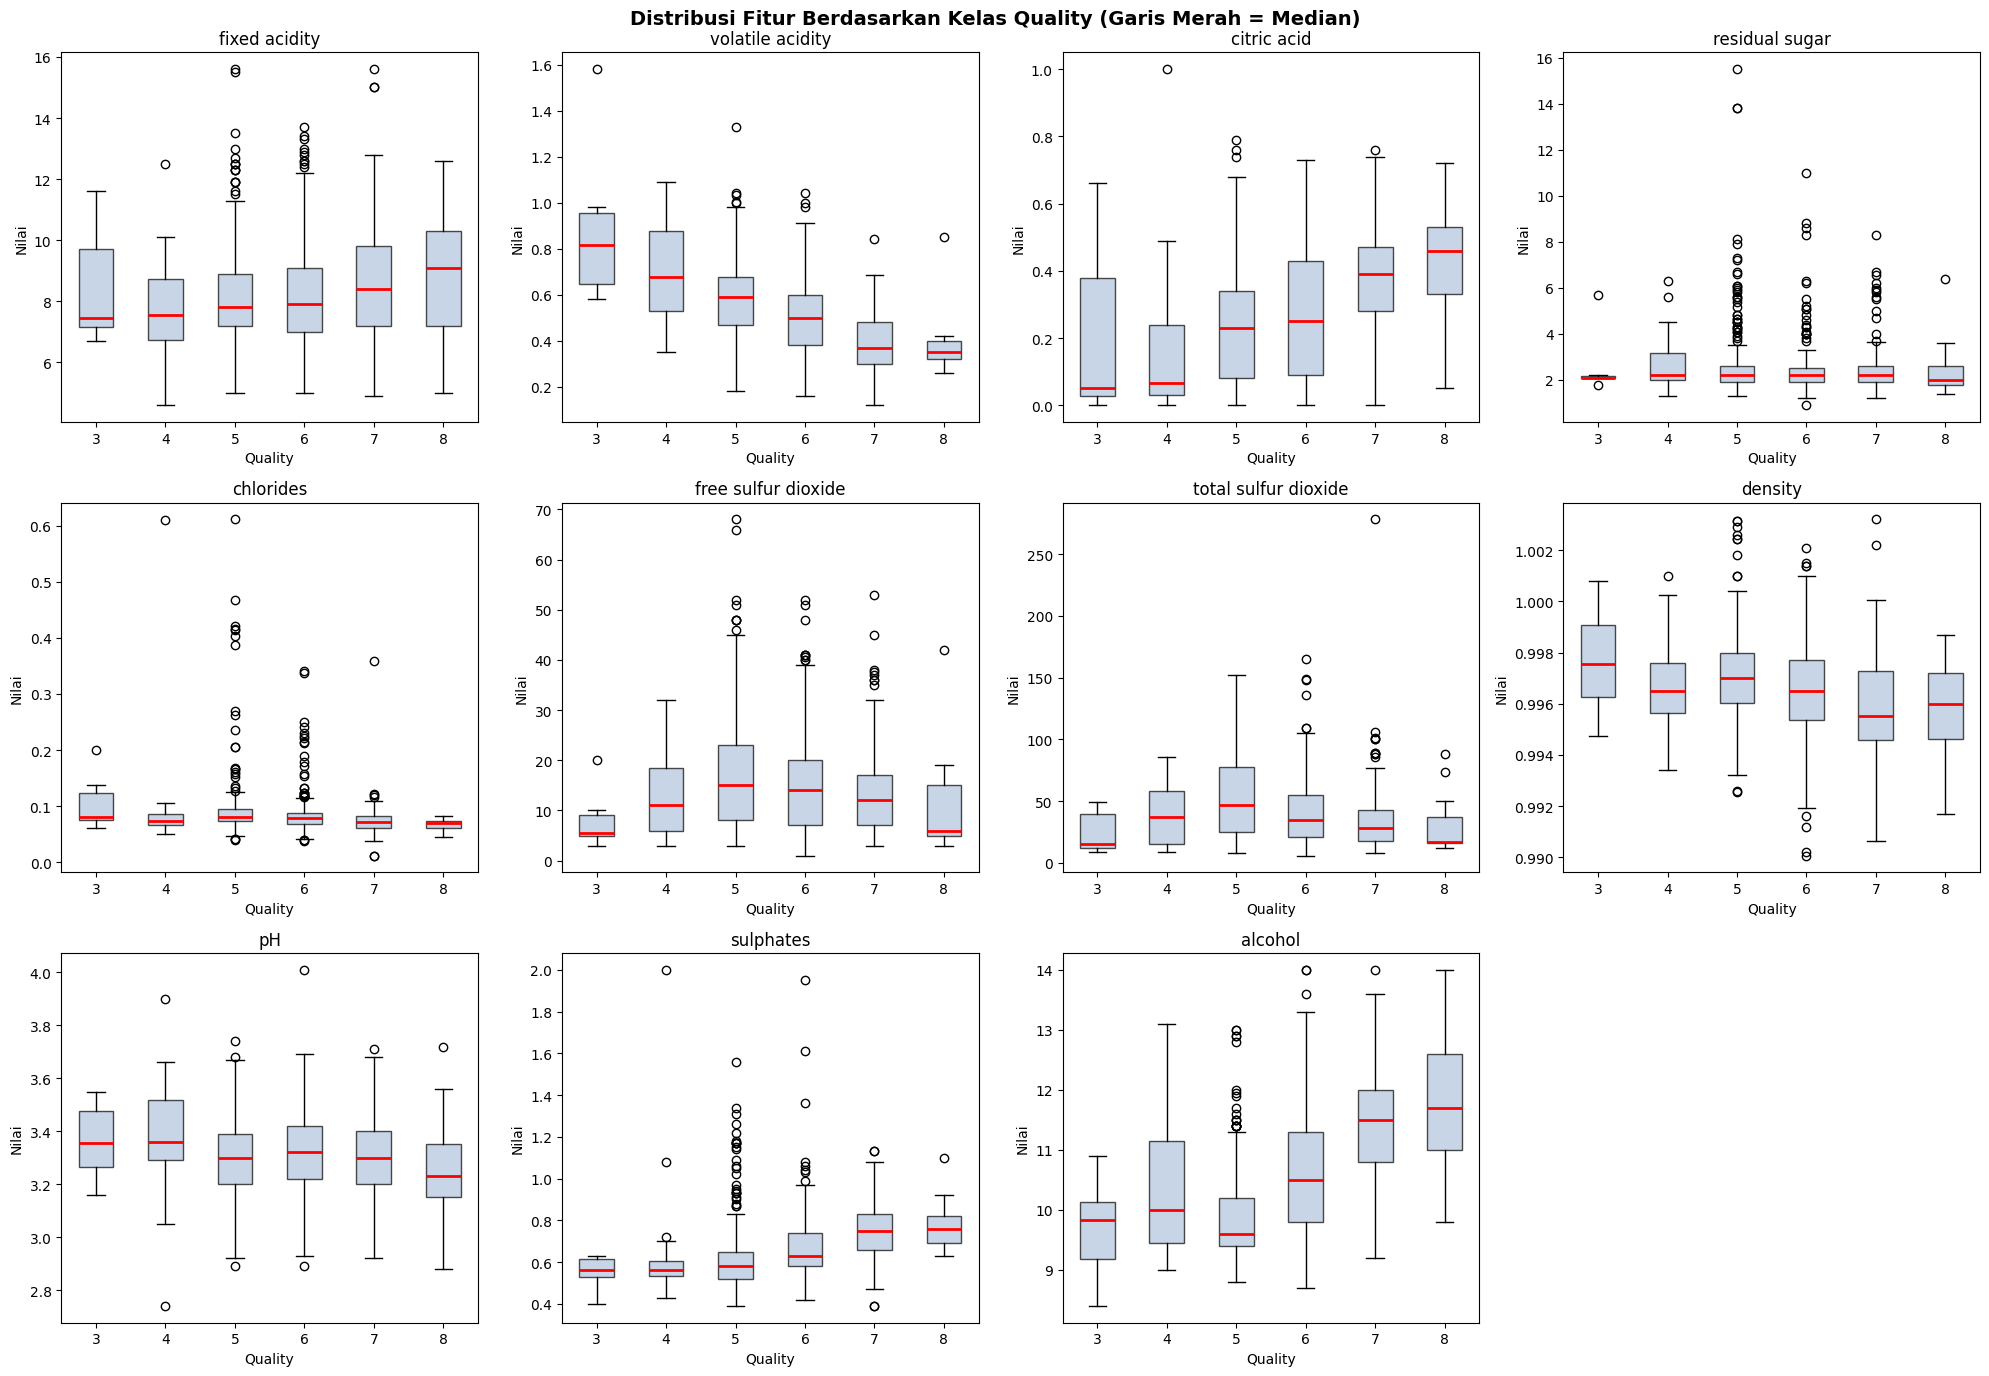

In [54]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
fig.suptitle('Distribusi Fitur Berdasarkan Kelas Quality (Garis Merah = Median)', fontsize=14, fontweight='bold')

for i, fitur in enumerate(fitur_kimia):
    quality_groups = [df_train[df_train['quality'] == q][fitur].values
                      for q in sorted(df_train['quality'].unique())]

    bp = axes[i].boxplot(quality_groups,
                         labels=sorted(df_train['quality'].unique()),
                         patch_artist=True,
                         medianprops=dict(color='red', linewidth=2))

    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue')
        patch.set_alpha(0.7)

    axes[i].set_title(fitur)
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel('Nilai')

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Boxplot per fitur menunjukkan bahwa alcohol, volatile acidity, sulphates, dan citric acid memiliki perbedaan distribusi yang cukup jelas antar kelas quality. Fitur-fitur ini berpotensi menjadi pembeda kelas yang kuat dalam model klasifikasi. Sebaliknya, density dan pH menunjukkan distribusi yang relatif serupa antar kelas, mengindikasikan pengaruhnya yang lebih kecil terhadap prediksi kualitas.

**4. Tren Rata-rata Fitur Utama Berdasarkan Kelas Quality**

Grafik line di bawah menampilkan tren rata-rata dari empat fitur utama berdasarkan kelas quality, untuk melihat pola hubungan antara fitur dan kualitas anggur secara lebih jelas.

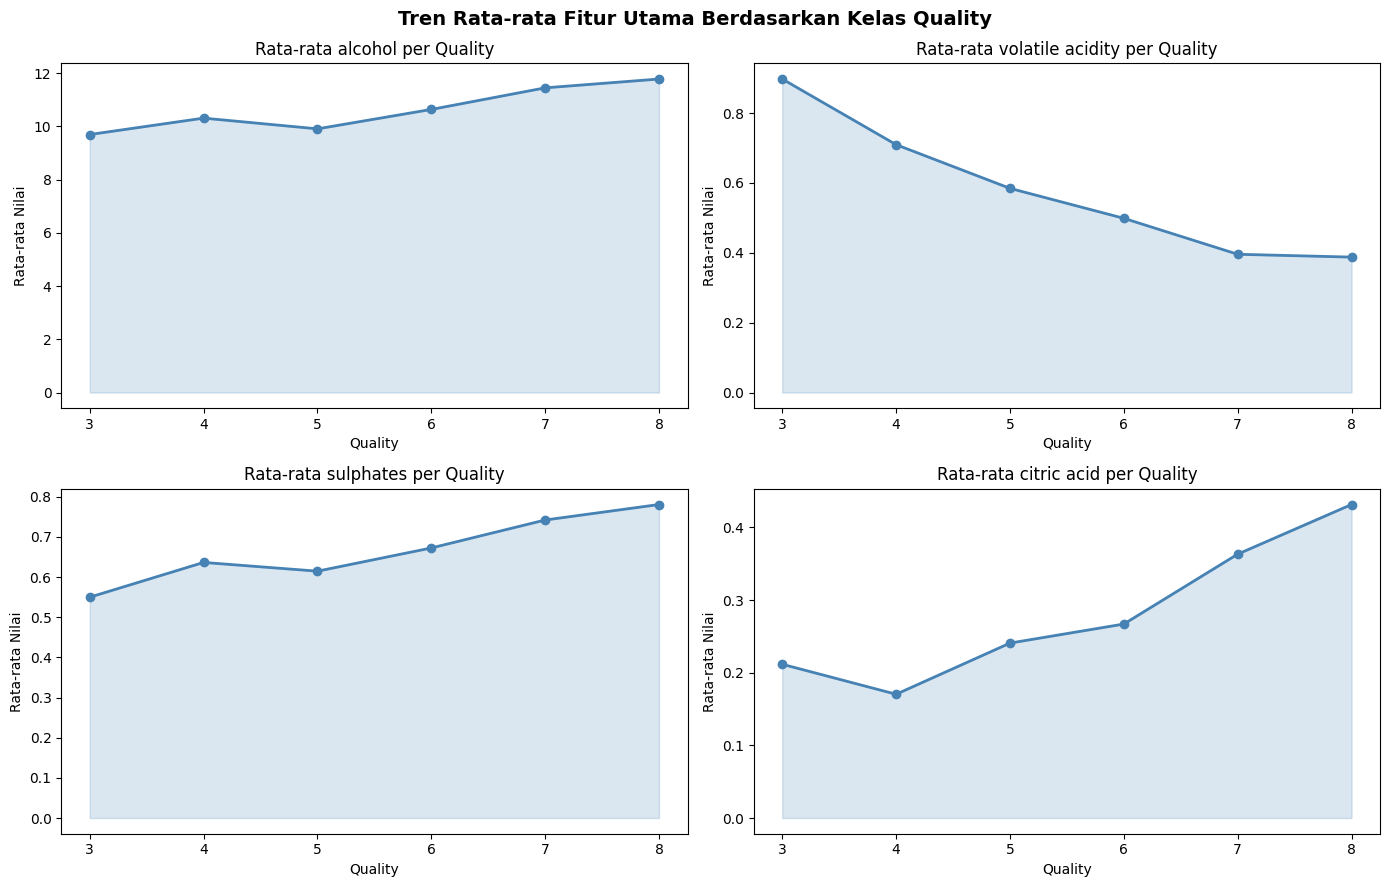

In [55]:
fitur_utama = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
quality_order = sorted(df_train['quality'].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
fig.suptitle('Tren Rata-rata Fitur Utama Berdasarkan Kelas Quality', fontsize=14, fontweight='bold')

for i, fitur in enumerate(fitur_utama):
    rata_rata = [df_train[df_train['quality'] == q][fitur].mean() for q in quality_order]

    axes[i].fill_between(quality_order, rata_rata, alpha=0.2, color='steelblue')
    axes[i].plot(quality_order, rata_rata, marker='o', color='steelblue', linewidth=2)
    axes[i].set_title(f'Rata-rata {fitur} per Quality')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel('Rata-rata Nilai')
    axes[i].set_xticks(quality_order)

plt.tight_layout()
plt.show()

Tren yang terlihat sangat jelas:

Alcohol → tren naik seiring peningkatan quality. Anggur berkualitas tinggi cenderung memiliki kadar alkohol lebih tinggi.

Volatile acidity → tren turun seiring peningkatan quality. Kadar asam volatil yang tinggi menurunkan kualitas rasa anggur.

Sulphates → tren naik — sulphates berperan sebagai pengawet yang menjaga kualitas anggur.

Citric acid → tren naik — asam sitrat menambah kesegaran dan kompleksitas rasa anggur.

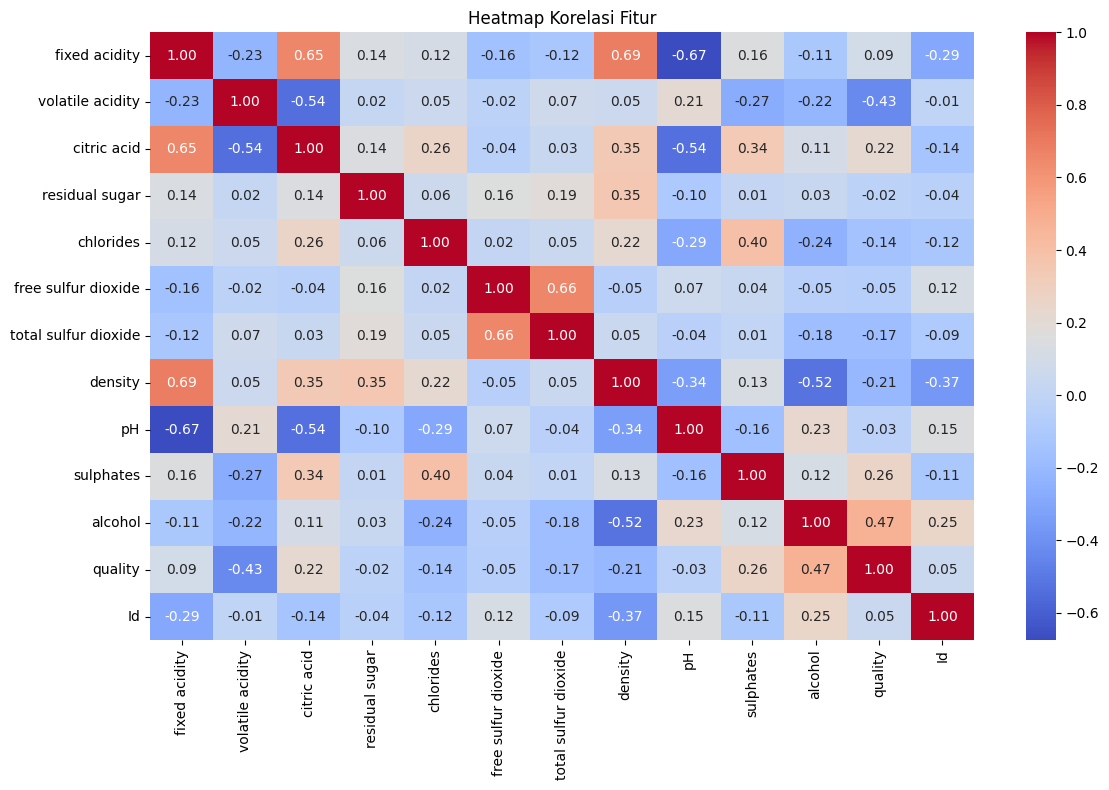

In [56]:
# Heatmap korelasi antar fitur
plt.figure(figsize=(12, 8))
sb.heatmap(df_train.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

Heatmap korelasi menunjukkan hubungan linear antar fitur. Fitur `alcohol` memiliki korelasi positif yang cukup kuat terhadap `quality`, artinya anggur dengan kadar alkohol lebih tinggi cenderung memiliki kualitas lebih baik. Sebaliknya, `volatile acidity` berkorelasi negatif dengan `quality`.

---
## 4. Pembersihan Data

Tahap ini bertujuan memastikan data bersih dari nilai yang hilang (missing values) dan duplikasi.

In [57]:
# Cek missing values
print('Missing values per kolom:')
print(df_train.isnull().sum())

Missing values per kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [58]:
# Hapus baris dengan missing values (jika ada)
df_train = df_train.dropna()

# Cek dan hapus duplikat
print('Jumlah duplikat sebelum dihapus:', df_train.duplicated().sum())
df_train = df_train.drop_duplicates()
print('Jumlah duplikat setelah dihapus :', df_train.duplicated().sum())

print('\nShape data training setelah cleaning:', df_train.shape)

Jumlah duplikat sebelum dihapus: 0
Jumlah duplikat setelah dihapus : 0

Shape data training setelah cleaning: (857, 13)


Setelah proses pembersihan, dataset tidak mengandung nilai yang hilang maupun data duplikat. Data siap digunakan untuk proses pelatihan model.

---
## 5. Persiapan Fitur dan Target

Dataset dipisahkan menjadi variabel independen (fitur, `x`) dan variabel dependen (target, `y`). Kolom `Id` dipisahkan dari data testing untuk digunakan kembali saat menyimpan hasil prediksi.

In [59]:
# Pisahkan fitur dan target dari data training
x = df_train.drop(columns=['quality', 'Id'])
y = df_train['quality']

# Siapkan data testing
test_ids     = df_test['Id']
x_test_final = df_test.drop(columns=['Id'])

print('Jumlah fitur :', x.shape[1])
print('Jumlah data  :', x.shape[0])
x.head()

Jumlah fitur : 11
Jumlah data  : 857


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0


In [60]:
y.head()

,quality
0,5
1,5
2,7
3,6
4,6


---
## 6. Split Data Training dan Validasi

Data training dibagi menjadi dua bagian: 70% untuk melatih model dan 30% untuk mengevaluasi performa model secara lokal. Pembagian ini dilakukan secara acak dengan `random_state=1` agar hasil dapat direproduksi.

In [61]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1
)

print('Ukuran data train :', x_train.shape)
print('Ukuran data test  :', x_test.shape)
x_train

Ukuran data train : (599, 11)
Ukuran data test  : (258, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
430,6.5,0.670,0.00,4.3,0.057,11.0,20.0,0.99488,3.45,0.56,11.8
486,8.9,0.590,0.39,2.3,0.095,5.0,22.0,0.99860,3.37,0.58,10.3
246,7.9,0.660,0.00,1.4,0.096,6.0,13.0,0.99569,3.43,0.58,9.5
40,6.7,0.280,0.28,2.4,0.012,36.0,100.0,0.99064,3.26,0.39,11.7
89,7.4,0.740,0.07,1.7,0.086,15.0,48.0,0.99502,3.12,0.48,10.0
...,...,...,...,...,...,...,...,...,...,...,...
715,10.0,0.430,0.33,2.7,0.095,28.0,89.0,0.99840,3.22,0.68,10.0
767,7.4,0.390,0.48,2.0,0.082,14.0,67.0,0.99720,3.34,0.55,9.2
72,5.3,0.570,0.01,1.7,0.054,5.0,27.0,0.99340,3.57,0.84,12.5
235,11.3,0.340,0.45,2.0,0.082,6.0,15.0,0.99880,2.94,0.66,9.2


In [62]:
x_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
750,7.7,0.18,0.34,2.7,0.066,15.0,58.0,0.99470,3.37,0.78,11.8
350,8.6,0.55,0.09,3.3,0.068,8.0,17.0,0.99735,3.23,0.44,10.0
666,6.8,0.59,0.10,1.7,0.063,34.0,53.0,0.99580,3.41,0.67,9.7
81,7.4,0.47,0.46,2.2,0.114,7.0,20.0,0.99647,3.32,0.63,10.5
484,6.9,0.40,0.14,2.4,0.085,21.0,40.0,0.99680,3.43,0.63,9.7
...,...,...,...,...,...,...,...,...,...,...,...
76,6.6,0.52,0.08,2.4,0.070,13.0,26.0,0.99358,3.40,0.72,12.5
842,8.2,0.51,0.24,2.0,0.079,16.0,86.0,0.99764,3.34,0.64,9.5
399,11.2,0.40,0.50,2.0,0.099,19.0,50.0,0.99783,3.10,0.58,10.4
734,6.6,0.52,0.04,2.2,0.069,8.0,15.0,0.99560,3.40,0.63,9.4


---
## 7. Model 1 — Logistic Regression

Logistic Regression adalah model klasifikasi linear yang bekerja dengan menghitung probabilitas suatu data termasuk ke dalam kelas tertentu. Meskipun sederhana, model ini sering digunakan sebagai **baseline** karena mudah diinterpretasikan dan cepat dilatih.

In [63]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train, y_train)

pred_lr = logistic_model.predict(x_test)

# Tampilkan perbandingan prediksi vs aktual
x_test1 = x_test.copy()
x_test1['quality_pred']   = pred_lr
x_test1['quality_actual'] = y_test
x_test1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_pred,quality_actual
750,7.7,0.18,0.34,2.7,0.066,15.0,58.0,0.99470,3.37,0.78,11.8,7,6
350,8.6,0.55,0.09,3.3,0.068,8.0,17.0,0.99735,3.23,0.44,10.0,5,5
666,6.8,0.59,0.10,1.7,0.063,34.0,53.0,0.99580,3.41,0.67,9.7,5,5
81,7.4,0.47,0.46,2.2,0.114,7.0,20.0,0.99647,3.32,0.63,10.5,6,5
484,6.9,0.40,0.14,2.4,0.085,21.0,40.0,0.99680,3.43,0.63,9.7,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,6.6,0.52,0.08,2.4,0.070,13.0,26.0,0.99358,3.40,0.72,12.5,6,7
842,8.2,0.51,0.24,2.0,0.079,16.0,86.0,0.99764,3.34,0.64,9.5,5,6
399,11.2,0.40,0.50,2.0,0.099,19.0,50.0,0.99783,3.10,0.58,10.4,6,5
734,6.6,0.52,0.04,2.2,0.069,8.0,15.0,0.99560,3.40,0.63,9.4,5,6


Tabel di atas menambahkan kolom `quality_pred` (hasil prediksi model) dan `quality_actual` (nilai kualitas sesungguhnya) ke dalam dataset testing untuk memudahkan perbandingan secara langsung.

In [64]:
acc_lr = accuracy_score(y_test, pred_lr) * 100
print(f'Akurasi Logistic Regression: {acc_lr:.2f}%')

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, pred_lr))

print('\nClassification Report:')
print(classification_report(y_test, pred_lr))

Akurasi Logistic Regression: 63.57%

Confusion Matrix:
[[ 0  0  3  0  0  0]
 [ 0  0  2  2  0  0]
 [ 0  0 97 20  0  0]
 [ 0  0 37 62 11  0]
 [ 0  0  1 13  5  0]
 [ 0  0  0  4  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.69      0.83      0.75       117
           6       0.61      0.56      0.59       110
           7       0.29      0.26      0.28        19
           8       0.00      0.00      0.00         5

    accuracy                           0.64       258
   macro avg       0.27      0.28      0.27       258
weighted avg       0.60      0.64      0.61       258



Logistic Regression memberikan akurasi sebagai baseline awal. Confusion matrix menunjukkan seberapa banyak prediksi yang benar dan salah untuk setiap kelas. Model linear ini kemungkinan besar belum mampu menangkap pola kompleks dan non-linear dalam data kimiawi anggur, sehingga perlu dibandingkan dengan model yang lebih kompleks.

---
## 8. Model 2 — K-Nearest Neighbors (KNN)

KNN adalah algoritma yang mengklasifikasikan data baru berdasarkan mayoritas kelas dari K tetangga terdekatnya dalam ruang fitur. Pemilihan nilai K yang tepat sangat penting — nilai K terlalu kecil dapat menyebabkan **overfitting**, sedangkan terlalu besar dapat menyebabkan **underfitting**.

In [65]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)
acc_knn = accuracy_score(y_test, y_pred_knn) * 100
print(f'Akurasi KNN (K=7): {acc_knn:.2f}%')

Akurasi KNN (K=7): 50.00%


In [66]:
# Mencari nilai K terbaik
neighbors_list = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
train_accuracy_list, test_accuracy_list = [], []

for neighbor_num in neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=neighbor_num)
    knn.fit(x_train, y_train)

    train_pred = knn.predict(x_train)
    test_pred  = knn.predict(x_test)
    train_acc  = accuracy_score(y_train, train_pred) * 100
    test_acc   = accuracy_score(y_test, test_pred) * 100

    train_accuracy_list.append(train_acc)
    test_accuracy_list.append(test_acc)
    print('Neighbors_num: {0} --> Accuracy on Test Set: {1} %'.format(
        neighbor_num, np.round(test_acc, 2)))

Neighbors_num: 1 --> Accuracy on Test Set: 50.39 %
Neighbors_num: 3 --> Accuracy on Test Set: 46.9 %
Neighbors_num: 5 --> Accuracy on Test Set: 51.55 %
Neighbors_num: 7 --> Accuracy on Test Set: 50.0 %
Neighbors_num: 9 --> Accuracy on Test Set: 53.49 %
Neighbors_num: 11 --> Accuracy on Test Set: 53.88 %
Neighbors_num: 13 --> Accuracy on Test Set: 58.14 %
Neighbors_num: 15 --> Accuracy on Test Set: 56.59 %
Neighbors_num: 17 --> Accuracy on Test Set: 52.71 %
Neighbors_num: 19 --> Accuracy on Test Set: 53.49 %
Neighbors_num: 21 --> Accuracy on Test Set: 51.55 %


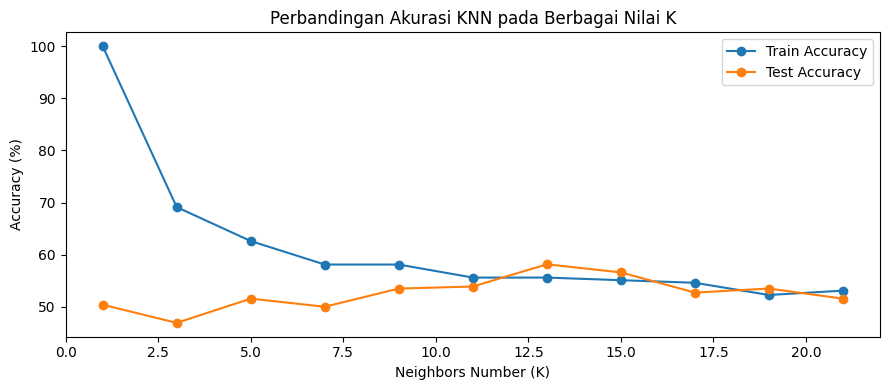

In [67]:
performance_df = pd.DataFrame({
    'Neighbors_num' : neighbors_list,
    'Train Accuracy': train_accuracy_list,
    'Test Accuracy' : test_accuracy_list
})

plt.figure(figsize=(9, 4))
plt.plot(performance_df['Neighbors_num'], performance_df['Train Accuracy'], marker='o', label='Train Accuracy')
plt.plot(performance_df['Neighbors_num'], performance_df['Test Accuracy'],  marker='o', label='Test Accuracy')
plt.xlabel('Neighbors Number (K)')
plt.ylabel('Accuracy (%)')
plt.title('Perbandingan Akurasi KNN pada Berbagai Nilai K')
plt.legend()
plt.tight_layout()
plt.show()

Grafik di atas menunjukkan bahwa semakin besar nilai K, akurasi pada data training cenderung turun karena model menjadi lebih general. Namun akurasi pada data test bisa meningkat hingga titik tertentu sebelum akhirnya menurun. Nilai K yang menghasilkan test accuracy tertinggi adalah K yang optimal untuk digunakan.

In [68]:
print('Confusion Matrix KNN:')
print(confusion_matrix(y_test, y_pred_knn))
print('\nClassification Report KNN:')
print(classification_report(y_test, y_pred_knn))

Confusion Matrix KNN:
[[ 0  0  2  0  1  0]
 [ 0  0  2  2  0  0]
 [ 0  1 75 38  3  0]
 [ 0  0 52 52  6  0]
 [ 0  0  9  8  2  0]
 [ 0  0  2  2  1  0]]

Classification Report KNN:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.53      0.64      0.58       117
           6       0.51      0.47      0.49       110
           7       0.15      0.11      0.12        19
           8       0.00      0.00      0.00         5

    accuracy                           0.50       258
   macro avg       0.20      0.20      0.20       258
weighted avg       0.47      0.50      0.48       258



---
## 9. Model 3 — Decision Tree

Decision Tree bekerja dengan membagi data secara rekursif berdasarkan fitur yang paling efektif memisahkan kelas. Keunggulannya adalah mudah divisualisasikan dan diinterpretasikan. Namun, tanpa pembatasan kedalaman, pohon cenderung **overfitting** terhadap data training.

In [69]:
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(x_train, y_train)

y_pred_dt = classifier.predict(x_test)

print('Confusion Matrix Decision Tree:')
print(confusion_matrix(y_test, y_pred_dt))
print('\nClassification Report Decision Tree:')
print(classification_report(y_test, y_pred_dt))

Confusion Matrix Decision Tree:
[[ 0  1  1  1  0  0]
 [ 0  0  2  0  1  1]
 [ 1  5 66 42  3  0]
 [ 0  2 34 57 13  4]
 [ 0  0  1  7  9  2]
 [ 1  0  0  0  3  1]]

Classification Report Decision Tree:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.63      0.56      0.60       117
           6       0.53      0.52      0.53       110
           7       0.31      0.47      0.38        19
           8       0.12      0.20      0.15         5

    accuracy                           0.52       258
   macro avg       0.27      0.29      0.28       258
weighted avg       0.54      0.52      0.53       258



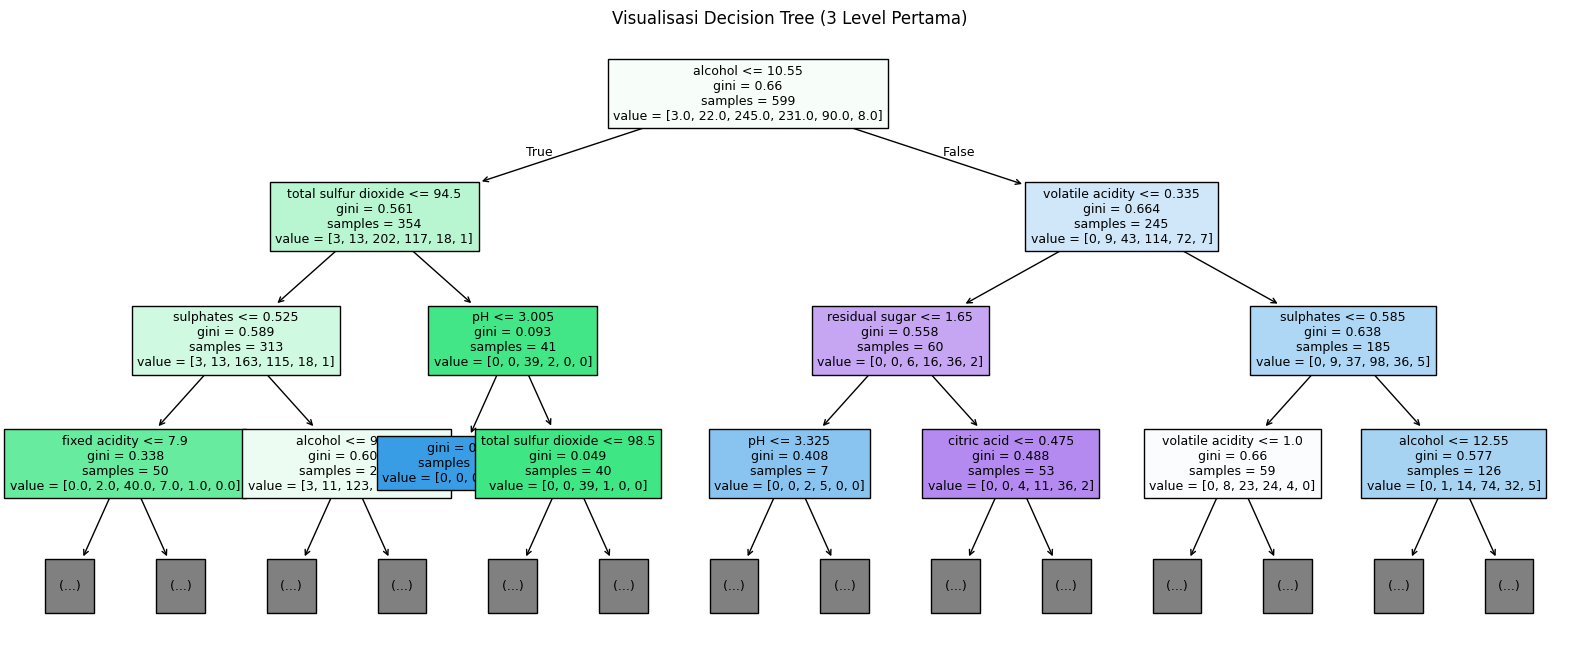

In [70]:
# Visualisasi pohon (dibatasi max_depth=3 agar lebih mudah dibaca)
plt.figure(figsize=(20, 8))
plot_tree(classifier, max_depth=3, filled=True, feature_names=x.columns.tolist(), fontsize=9)
plt.title('Visualisasi Decision Tree (3 Level Pertama)')
plt.show()

Visualisasi pohon menunjukkan bagaimana model membelah data berdasarkan fitur tertentu di setiap node. Node dengan warna lebih gelap menunjukkan dominansi kelas yang lebih kuat. Fitur yang muncul di bagian atas pohon (root) adalah fitur yang paling informatif dan berpengaruh dalam menentukan kualitas anggur.

### 9.1 Tuning Decision Tree dengan GridSearchCV

Untuk menemukan kombinasi hyperparameter terbaik, digunakan `GridSearchCV` yang mencoba semua kombinasi parameter secara sistematis menggunakan cross-validation. Dengan cara ini, model dapat dioptimalkan tanpa bergantung pada tebakan manual.

In [71]:
tree_params_list = {
    'max_depth': np.arange(1, 20, 2),
    'criterion': ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_params_list,
    cv=StratifiedKFold(n_splits=3),
    scoring='accuracy'
)
grid_search.fit(x_train, y_train)

print('Parameter terbaik:', grid_search.best_params_)
grid_search.best_estimator_

Parameter terbaik: {'criterion': 'gini', 'max_depth': np.int64(5)}


DecisionTreeClassifier(max_depth=np.int64(5), random_state=42)

In [72]:
best_dt_model = grid_search.best_estimator_
y_best_dt = best_dt_model.predict(x_test)

acc_dt_tuned = accuracy_score(y_test, y_best_dt) * 100
print(f'Akurasi Decision Tree (Tuned): {acc_dt_tuned:.2f}%')

print('\nConfusion Matrix Decision Tree (Tuned):')
print(confusion_matrix(y_test, y_best_dt))
print('\nClassification Report Decision Tree (Tuned):')
print(classification_report(y_test, y_best_dt))

Akurasi Decision Tree (Tuned): 55.43%

Confusion Matrix Decision Tree (Tuned):
[[ 0  1  2  0  0  0]
 [ 0  0  3  1  0  0]
 [ 0  1 83 32  1  0]
 [ 0  0 46 56  8  0]
 [ 0  0  1 14  4  0]
 [ 0  0  0  4  1  0]]

Classification Report Decision Tree (Tuned):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.61      0.71      0.66       117
           6       0.52      0.51      0.52       110
           7       0.29      0.21      0.24        19
           8       0.00      0.00      0.00         5

    accuracy                           0.55       258
   macro avg       0.24      0.24      0.24       258
weighted avg       0.52      0.55      0.54       258



Setelah dilakukan tuning dengan GridSearchCV, Decision Tree dengan parameter optimal menghasilkan performa yang lebih baik dibandingkan Decision Tree default. Ini menunjukkan bahwa pemilihan hyperparameter yang tepat — khususnya `max_depth` dan `criterion` — berpengaruh signifikan terhadap kualitas model.

---
## 10. Model 4 — Random Forest

Random Forest adalah metode **ensemble** yang membangun banyak Decision Tree secara paralel dengan subset data dan fitur yang berbeda-beda, lalu menggabungkan hasilnya melalui voting mayoritas. Metode ini umumnya menghasilkan performa lebih tinggi dan lebih tahan terhadap overfitting dibandingkan Decision Tree tunggal.

In [73]:
rfc = RandomForestClassifier(n_estimators=200, random_state=0)
rfc.fit(x_train, y_train)

y_pred_rfc = rfc.predict(x_test)

print('Model accuracy score Random Forest: {0:0.4f}'.format(
    accuracy_score(y_test, y_pred_rfc)))

Model accuracy score Random Forest: 0.6473


In [74]:
acc_rfc = accuracy_score(y_test, y_pred_rfc) * 100
print(f'Akurasi Random Forest: {acc_rfc:.2f}%')

print('\nConfusion Matrix Random Forest:')
print(confusion_matrix(y_test, y_pred_rfc))
print('\nClassification Report Random Forest:')
print(classification_report(y_test, y_pred_rfc))

Akurasi Random Forest: 64.73%

Confusion Matrix Random Forest:
[[ 0  0  3  0  0  0]
 [ 0  0  4  0  0  0]
 [ 0  0 90 24  3  0]
 [ 0  1 32 68  9  0]
 [ 0  0  1  9  8  1]
 [ 0  0  0  2  2  1]]

Classification Report Random Forest:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.69      0.77      0.73       117
           6       0.66      0.62      0.64       110
           7       0.36      0.42      0.39        19
           8       0.50      0.20      0.29         5

    accuracy                           0.65       258
   macro avg       0.37      0.33      0.34       258
weighted avg       0.63      0.65      0.64       258



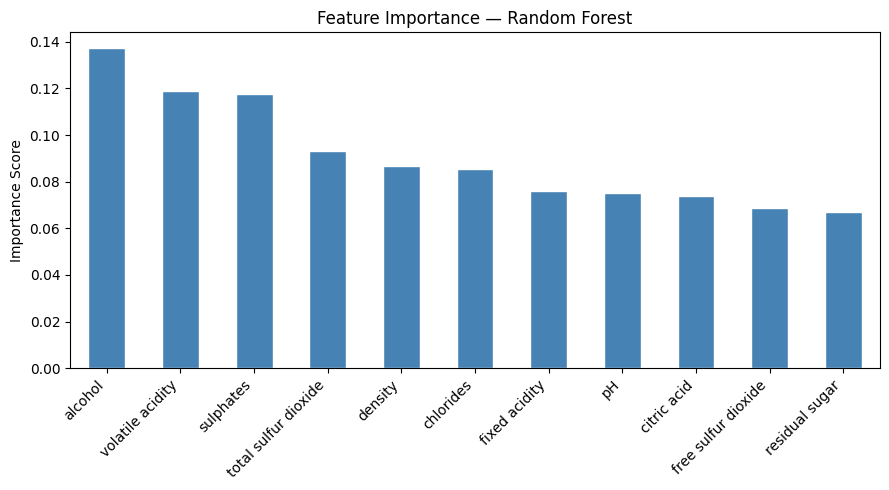

In [75]:
# Feature Importance
feat_imp = pd.Series(rfc.feature_importances_, index=x.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

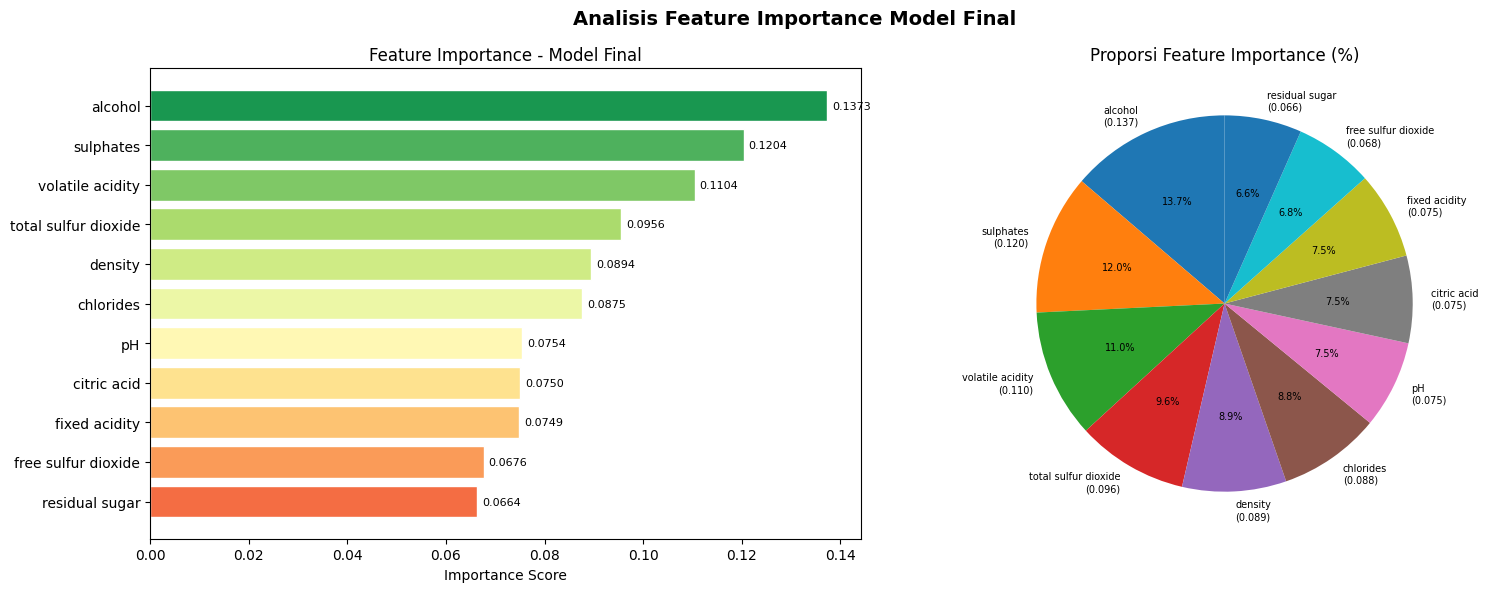

In [76]:
x = df_train.drop(columns=['quality', 'Id'])
y = df_train['quality']

final_model = RandomForestClassifier(n_estimators=200, random_state=0)
final_model.fit(x, y)

# Feature importance
importance_scores = final_model.feature_importances_
importance_df = pd.Series(importance_scores, index=x.columns).sort_values(ascending=True)
importance_pct = importance_scores / importance_scores.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Feature Importance Model Final', fontsize=14, fontweight='bold')

# --- Plot 1: Horizontal bar chart ---
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importance_df)))
bars = axes[0].barh(importance_df.index, importance_df.values, color=colors, edgecolor='white')
axes[0].set_title('Feature Importance - Model Final')
axes[0].set_xlabel('Importance Score')

for bar, val in zip(bars, importance_df.values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

# --- Plot 2: Pie chart proporsi ---
importance_sorted = pd.Series(importance_scores, index=x.columns).sort_values(ascending=False)
labels_pct = [f'{name}\n({val:.3f})' for name, val in importance_sorted.items()]

axes[1].pie(importance_sorted.values,
            labels=labels_pct,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 7})
axes[1].set_title('Proporsi Feature Importance (%)')

plt.tight_layout()
plt.show()

Grafik feature importance menunjukkan fitur mana yang paling berpengaruh dalam prediksi kualitas anggur oleh model Random Forest. Fitur dengan skor importance tertinggi berarti fitur tersebut paling sering dan efektif digunakan oleh pohon-pohon dalam forest saat membuat keputusan klasifikasi. Fitur seperti `alcohol`, `sulphates` dan `volatile acidity` umumnya memiliki importance yang tinggi pada dataset ini.



---
## 11. Perbandingan Semua Model

Setelah semua model dilatih dan dievaluasi, hasil akurasi masing-masing model dibandingkan secara menyeluruh untuk menentukan model terbaik yang akan digunakan dalam prediksi data testing.

                Model  Accuracy (%)
        Random Forest     64.728682
  Logistic Regression     63.565891
Decision Tree (Tuned)     55.426357
        Decision Tree     51.550388
            KNN (K=7)     50.000000


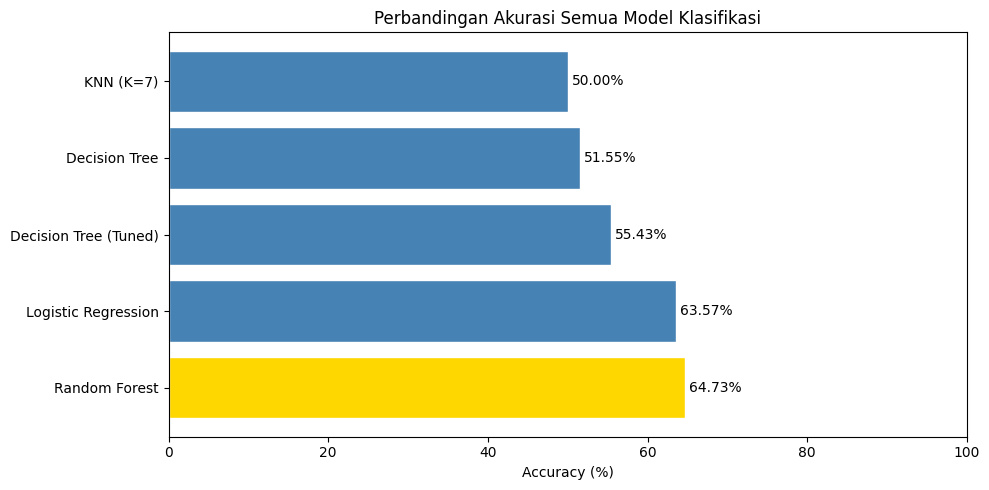

In [77]:
results = {
    'Logistic Regression'    : accuracy_score(y_test, pred_lr) * 100,
    'KNN (K=7)'              : accuracy_score(y_test, y_pred_knn) * 100,
    'Decision Tree'          : accuracy_score(y_test, y_pred_dt) * 100,
    'Decision Tree (Tuned)'  : accuracy_score(y_test, y_best_dt) * 100,
    'Random Forest'          : accuracy_score(y_test, y_pred_rfc) * 100,
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy (%)'])
results_df = results_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# Visualisasi perbandingan
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
plt.barh(results_df['Model'], results_df['Accuracy (%)'], color=colors, edgecolor='white')
plt.xlabel('Accuracy (%)')
plt.title('Perbandingan Akurasi Semua Model Klasifikasi')
plt.xlim(0, 100)
for i, v in enumerate(results_df['Accuracy (%)']):
    plt.text(v + 0.5, i, f'{v:.2f}%', va='center')
plt.tight_layout()
plt.show()

---
## 12. Kesimpulan Pemilihan Model

Berdasarkan hasil perbandingan akurasi di atas, **Random Forest** menghasilkan akurasi tertinggi dibandingkan model lainnya. Hal ini dapat dijelaskan karena:

1. Random Forest merupakan metode **ensemble** yang menggabungkan prediksi dari banyak Decision Tree, sehingga lebih stabil dan akurat.
2. Random Forest mampu menangani **fitur dengan skala yang bervariasi** tanpa memerlukan normalisasi eksplisit.
3. Model ini lebih **tahan terhadap overfitting** dibandingkan Decision Tree tunggal karena menggunakan subset fitur secara acak di setiap tree.
4. Random Forest mampu menangkap **hubungan non-linear** yang tidak bisa ditangkap oleh Logistic Regression.

Oleh karena itu, **Random Forest** dipilih sebagai model final untuk memprediksi data testing.

---
## 13. Prediksi Data Testing

Model Random Forest dilatih ulang menggunakan **seluruh** data training (bukan hanya 70%) untuk memaksimalkan informasi yang dipelajari sebelum digunakan memprediksi data testing. Ini adalah praktik yang umum dilakukan setelah model final dipilih.

In [78]:
# Latih ulang dengan seluruh data training
final_model = RandomForestClassifier(n_estimators=200, random_state=0)
final_model.fit(x, y)

print('Model berhasil dilatih ulang dengan seluruh data training.')
print(f'Jumlah data training yang digunakan: {x.shape[0]} baris')

Model berhasil dilatih ulang dengan seluruh data training.
Jumlah data training yang digunakan: 857 baris


In [79]:
# Prediksi data testing
y_pred_final = final_model.predict(x_test_final)

# Buat dataframe hasil prediksi
hasil = pd.DataFrame({
    'Id'     : test_ids,
    'quality': y_pred_final
})

print('Hasil prediksi (10 data pertama):')
print(hasil.head(10))
print(f'\nTotal data yang diprediksi: {len(hasil)} baris')

Hasil prediksi (10 data pertama):
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        6
5  1120        6
6   180        5
7    82        5
8   632        6
9   592        5

Total data yang diprediksi: 286 baris


Distribusi hasil prediksi quality:
quality
5    132
6    125
7     29
Name: count, dtype: int64


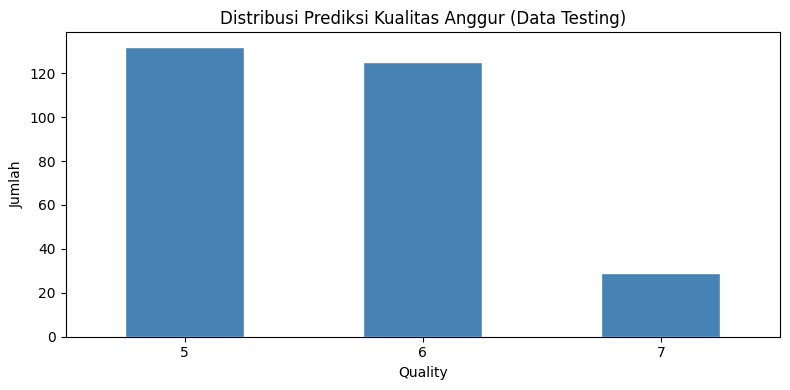

In [80]:
# Distribusi hasil prediksi
print('Distribusi hasil prediksi quality:')
print(hasil['quality'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
hasil['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribusi Prediksi Kualitas Anggur (Data Testing)')
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Distribusi hasil prediksi pada data testing menunjukkan pola yang serupa dengan data training, di mana kualitas 5 dan 6 mendominasi. Ini mengindikasikan bahwa model berhasil mempelajari distribusi kelas dengan baik dan tidak mengalami bias ekstrem ke salah satu kelas.

---
## 14. Simpan Hasil Prediksi ke CSV

Hasil prediksi disimpan dalam format CSV yang hanya memuat dua kolom: `Id` dan `quality`.

In [81]:
hasil.to_csv('hasil_prediksi.csv', index=False)
print('File hasil_prediksi.csv berhasil disimpan!')
print('Kolom yang tersimpan:', hasil.columns.tolist())
print('Jumlah baris        :', len(hasil))
from google.colab import files
files.download('hasil_prediksi.csv')

File hasil_prediksi.csv berhasil disimpan!
Kolom yang tersimpan: ['Id', 'quality']
Jumlah baris        : 286


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 15. Ringkasan Akhir

Berikut adalah rangkuman proses dan hasil yang telah dilakukan:

| Tahap | Keterangan |
|---|---|
| Dataset | Wine Quality (training + testing) |
| Fitur | 12 variabel kimiawi anggur |
| Target | `quality` (skala 0–10) |
| Pembersihan | Hapus missing values dan duplikat |
| Model yang diuji | Logistic Regression, KNN, Decision Tree, Random Forest |
| Model terpilih | **Random Forest** (akurasi tertinggi) |
| Output | `hasil_prediksi.csv` (Id + quality) |

Model **Random Forest** dipilih karena menghasilkan akurasi tertinggi dalam evaluasi menggunakan data validasi. Model ini mampu menangkap pola kompleks dan non-linear dalam data kimiawi anggur serta memberikan prediksi yang lebih andal dibandingkan model lainnya